<a href="https://colab.research.google.com/github/avanigautam017/App_review_sentimental_analysis/blob/main/Amazon_review_sentimental_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#for amazon reviews---->
import numpy as np
import pandas as pd

In [ ]:
import csv
import pandas as pd

df = pd.read_csv(
    "/content/Amazon_Reviews.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL
)

In [ ]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21214 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21055 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


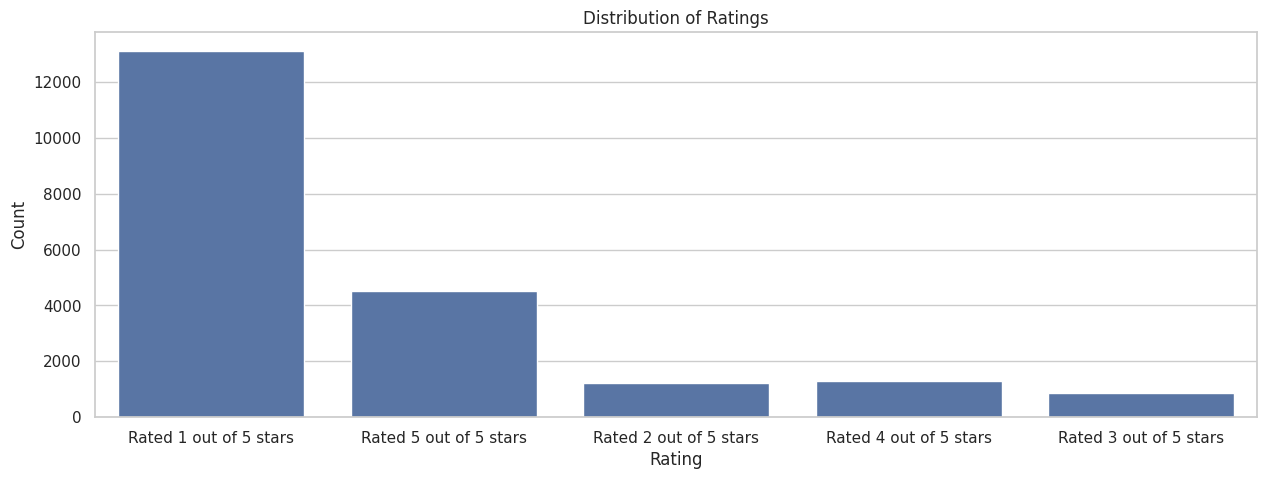

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(15,5))
sns.countplot(data=df,x='Rating')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:
from textblob import TextBlob

In [ ]:
def textblob_sentiment_analysis(reviews):
  sentiment=TextBlob(reviews).sentiment
  if sentiment.polarity>0.1:
    return 'Positive'
  elif sentiment.polarity<-0.1:
    return 'Negative'
  else:
    return 'Neutral'

In [ ]:
# Check how many missing values you have
print(df['Review Text'].isna().sum())

159


In [ ]:
# Replace missing values with an empty string before applying the function:
df['Sentiment'] = df['Review Text'].fillna('').apply(textblob_sentiment_analysis)

In [ ]:
df.sample(5)

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment
17429,Elizabeth Cawte,/users/5bbc89974de5666d3428562f,GB,5 reviews,2018-10-09T10:59:02.000Z,Rated 5 out of 5 stars,great platform for everything,Never had a problem with Amazons customer serv...,"October 09, 2018",Negative
13601,Ricky,/users/5a25e5880000ff000aec1154,US,3 reviews,2020-05-29T14:09:45.000Z,Rated 1 out of 5 stars,Number one they take your money then…,Number one they take your money then say if yo...,"May 29, 2020",Negative
13511,Hitesh Matai,/users/5edf36332bbe5485c5e0e748,IN,1 review,2020-06-09T07:12:04.000Z,Rated 1 out of 5 stars,Worst Customer service ever received…,Worst Customer service ever received ...they a...,"June 09, 2020",Neutral
20129,PETER BOUD,/users/4f8ec64f000064000117d4bc,GB,5 reviews,2012-04-18T13:50:46.000Z,Rated 4 out of 5 stars,Always provides a very good service and fast (...,I have always been very impressed with the ser...,"April 18, 2012",Positive
15548,Porsche,/users/5da93b8788d49a3a9ef58ef9,US,1 review,2019-10-18T04:11:53.000Z,Rated 1 out of 5 stars,They remove reviews that cost them money,"I would like to love this company; However, th...","October 18, 2019",Neutral


In [ ]:
# Analyzing App Reviews Sentiments

In [ ]:
sentiment_distribution=df['Sentiment'].value_counts()
sentiment_distribution

,count
Sentiment,
Neutral,8636
Positive,7345
Negative,5233


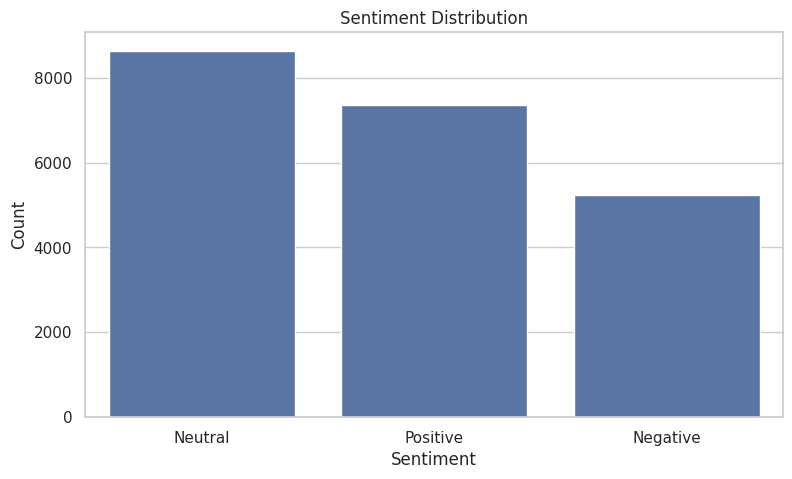

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(x=sentiment_distribution.index,
            y=sentiment_distribution.values)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

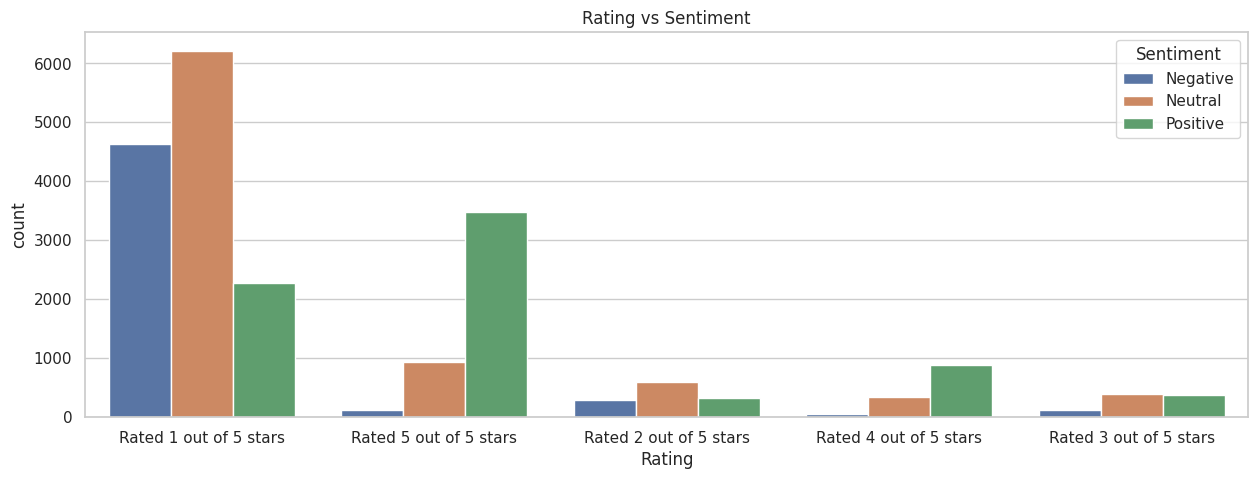

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(data=df, x='Rating', hue='Sentiment')
plt.title('Rating vs Sentiment')
plt.show()